Author: Esteban Alfaro 

Email: alfaro8511@gmail.com

Date: june 2023

Website: https://estebanalfaro328753397.wordpress.com/

Original images from Google Earth

In [2]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from skimage import io
import matplotlib.patches as mpatches

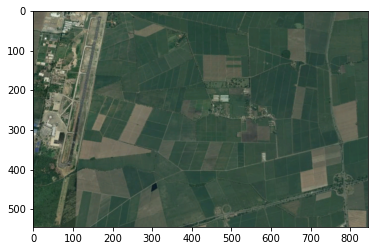

In [3]:
imagen = io.imread('imagenes_sensoresremotos/cana.tiff')  # leer imagen
plt.imshow(imagen)
plt.show()

In [4]:
rows, cols, bandas = imagen.shape
imagen_array = imagen.reshape(rows * cols, bandas)

In [5]:
#clustering kmeans
kmeans = KMeans(n_clusters=9,random_state=0) #crear modelo
kmeans.fit(imagen_array) #entrena modelo
labels = kmeans.labels_ #etiqueda las clases (asignación de cada pixel a un cluster específico)
centroides = kmeans.cluster_centers_ #coordeandas de los centroides (valores de los canales RGBA de los centroides)

/home/esteban/.local/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [6]:
imagen_clasificada = labels.reshape(rows, cols)

In [7]:
colores = [
    [0, 0, 0],       # Clase 0: Negro
    [255, 0, 0],     # Clase 1: Rojo
    [0, 255, 0],     # Clase 2: Verde
    [0, 0, 255],     # Clase 3: Azul
    [255, 255, 0],   # Clase 4: Amarillo
    [255, 0, 255],   # Clase 5: Magenta
    [0, 255, 255],   # Clase 6: Cian
    [128, 0, 0],     # Clase 7: Marrón
    [128, 128, 128]  # Clase 8: Gris
]

imagen_clasificada_rgb = np.zeros((rows, cols, 3), dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        imagen_clasificada_rgb[i, j] = colores[imagen_clasificada[i, j]]

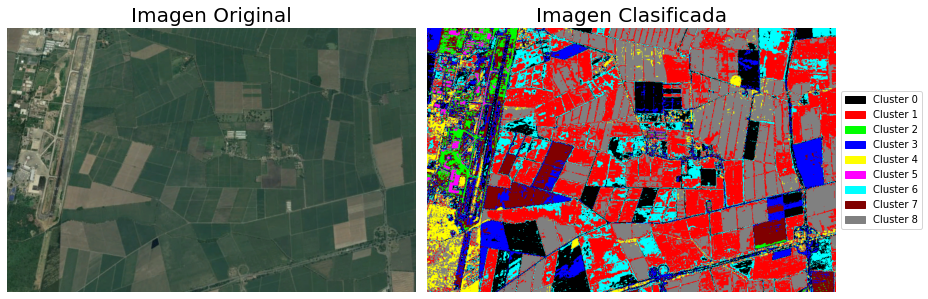

In [8]:
#figura con leyenda
# Configura la figura y los subplots
fig, axs = plt.subplots(1, 2, figsize=(13, 9))

# Grafica la imagen original en el primer subplot
axs[0].imshow(imagen)
axs[0].axis('off')
axs[0].set_title('Imagen Original',size=20)

# Grafica la imagen clasificada en el segundo subplot
axs[1].imshow(imagen_clasificada_rgb)
axs[1].axis('off')
axs[1].set_title('Imagen Clasificada',size=20)

# Crea la leyenda con el nombre de cada cluster y su respectivo color
colors = [
    [0, 0, 0],       # Clase 0: Negro
    [255, 0, 0],     # Clase 1: Rojo
    [0, 255, 0],     # Clase 2: Verde
    [0, 0, 255],     # Clase 3: Azul
    [255, 255, 0],   # Clase 4: Amarillo
    [255, 0, 255],   # Clase 5: Magenta
    [0, 255, 255],   # Clase 6: Cian
    [128, 0, 0],     # Clase 7: Marrón
    [128, 128, 128]  # Clase 8: Gris
]

labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6', 'Cluster 7', 'Cluster 8']

legend_patches = []
for color, label in zip(colors, labels):
    patch = mpatches.Patch(color=np.array(color) / 255.0, label=label)
    legend_patches.append(patch)

# Agrega la leyenda al segundo subplot, ubicada en el lado derecho y por fuera de la figura
axs[1].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5))

# Ajusta los espacios entre subplots
plt.tight_layout()

# Muestra la figura
plt.show()